# PIMA INDIANS DIABETES - CLASSIFICATION

## Version 4 - Feature Selection

### Khai báo thư viện nâng cao
- Sử dụng Pipeline để tránh rò rỉ dữ liệu (data leakage) và SimpleImputer để xử lý giá trị 0.

In [ ]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.base import BaseEstimator, TransformerMixin

## 1. Nạp dữ liệu

In [ ]:
data_path = os.path.join(os.getcwd(), "..", "data", "pima-indians-diabetes.csv")
col_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI","DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(data_path, header=None, names=col_names)
print(f"Đã nạp {len(df)} dòng dữ liệu.")
print(f"Shape: {df.shape}")
df.head(10)

Đã nạp 768 dòng dữ liệu.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Chia tập dữ liệu (Split Data)

- Chia dữ liệu: Tách cột mục tiêu Outcome (nhãn y) và các cột đặc trưng (X). Sau đó chia thành tập huấn luyện (70%) và tập kiểm tra (30%).

- BasePreprocessor: Đây là một lớp tùy chỉnh (Custom Transformer) dùng để xử lý các giá trị bằng 0 vô lý. Cụ thể, các giá trị 0 ở các cột như Glucose, BloodPressure, BMI... sẽ được thay thế bằng NaN để sau này có thể xử lý bằng phương pháp điền giá trị trung vị (median).

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
class BasePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cols] = X[self.cols].replace(0, np.nan)
        return X

- Hai đặc trưng mới được tạo ra:

  - BMI_Age: Tích của chỉ số khối cơ thể (BMI) và Tuổi (Age). Giả định rằng sự kết hợp giữa béo phì và tuổi tác cao làm tăng nguy cơ tiểu đường một cách đáng kể.

  - Glucose_BMI: Tích của lượng Đường trong máu (Glucose) và BMI. Đây là sự kết hợp giữa hai yếu tố nguy cơ hàng đầu.

In [ ]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Feature mới
        X["BMI_Age"] = X["BMI"] * X["Age"]
        X["Glucose_BMI"] = X["Glucose"] * X["BMI"]
        
        return X

## 3. Huấn luyện mô hình Baseline (Logistic Regression)

- Danh sách mô hình: Khởi tạo 4 thuật toán phổ biến:

  - LogisticRegression: Mô hình tuyến tính cơ bản.

  - RandomForestClassifier: Mô hình dựa trên cây quyết định (mạnh mẽ với dữ liệu bảng).

  - SVC: Mô hình Support Vector Machine.

  - KNeighborsClassifier: Mô hình dựa trên khoảng cách.

- Hàm run_pipeline: Đây là hàm cốt lõi giúp tự động hóa việc:

  - Sử dụng StratifiedKFold (kiểm chéo 5 phần) để đánh giá mô hình ổn định hơn trên tập huấn luyện.

  - Tính toán chỉ số F1-score (chỉ số quan trọng khi tập dữ liệu bị lệch nhãn).

  - Dự đoán trên tập kiểm tra (X_test) và trả về các chỉ số Accuracy, F1-score để so sánh.

In [ ]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

- Kiểm chéo (Cross Validation): Sử dụng StratifiedKFold chia dữ liệu thành 5 phần để tính điểm cv_f1. Việc này giúp xác định xem mô hình có hoạt động ổn định trên các tập dữ liệu khác nhau hay không.

- Huấn luyện lại (Training): Sau khi kiểm tra độ ổn định, mô hình thực hiện học trên toàn bộ tập X_train để tận dụng tối đa tri thức từ dữ liệu.

- Kiểm tra độc lập (Testing): Dự báo trên tập X_test (dữ liệu mô hình chưa từng thấy) để tính toán Accuracy và F1-score thực tế.

In [ ]:
def run_pipeline(name, pipeline):
    # define CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # cross validation
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    # train full train set
    pipeline.fit(X_train, y_train)

    # predict test
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        "method": name,
        "cv_f1": round(cv_scores.mean(), 4),
        "test_acc": round(acc, 4),
        "test_f1": round(f1, 4)
    }

## 4. Đánh giá chi tiết

- Trục tung (Actual): Giá trị thực tế của bệnh nhân.

- Trục hoành (Predicted): Giá trị mô hình dự đoán.

- Nó giúp nhận diện ngay lập tức mô hình đang đoán sai ở đâu: Nhầm người khỏe thành có bệnh (False Positive) hay bỏ sót người bệnh (False Negative).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - " + title)
    plt.tight_layout()
    plt.show()


===== Logistic =====


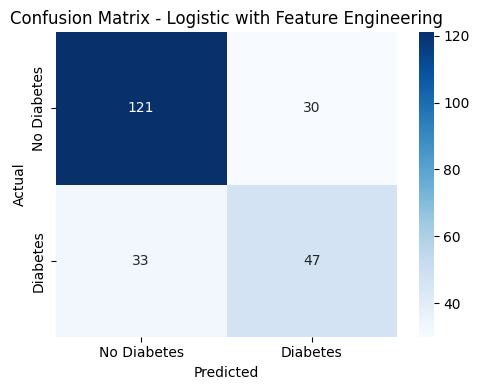


===== RandomForest =====


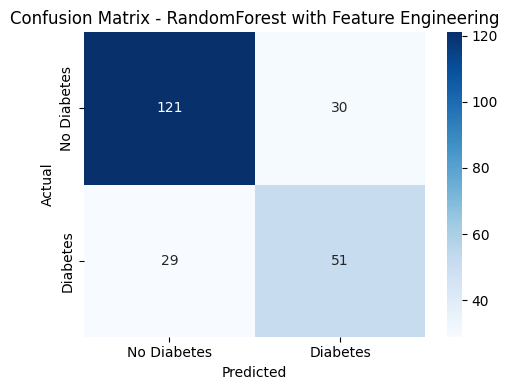


===== SVM =====


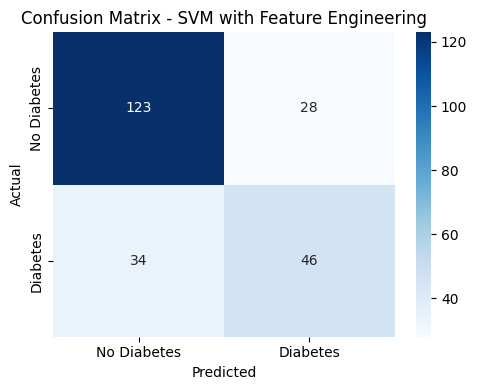


===== KNN =====


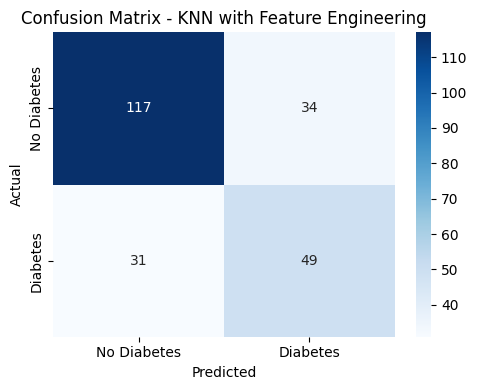

In [ ]:
results = []

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")

    use_scaler = model_name in ["Logistic", "SVM", "KNN"]

    steps = [
        ('base', BasePreprocessor()),
        ('feature', FeatureEngineering()),
        ('imputer', SimpleImputer(strategy='median'))
    ]

    if use_scaler:
        steps.append(('scaler', StandardScaler()))

    steps.append(('model', model))

    pipeline = Pipeline(steps)
    results.append(run_pipeline(f"{model_name}_feature", pipeline))
    
    plot_confusion_matrix(y_test, pipeline.predict(X_test), title=f"{model_name} with Feature Engineering")

,method,cv_f1,test_acc,test_f1
1,RandomForest_feature,0.6403,0.7446,0.6335
3,KNN_feature,0.5984,0.7186,0.6012
0,Logistic_feature,0.6463,0.7273,0.5987
2,SVM_feature,0.6345,0.7316,0.5974


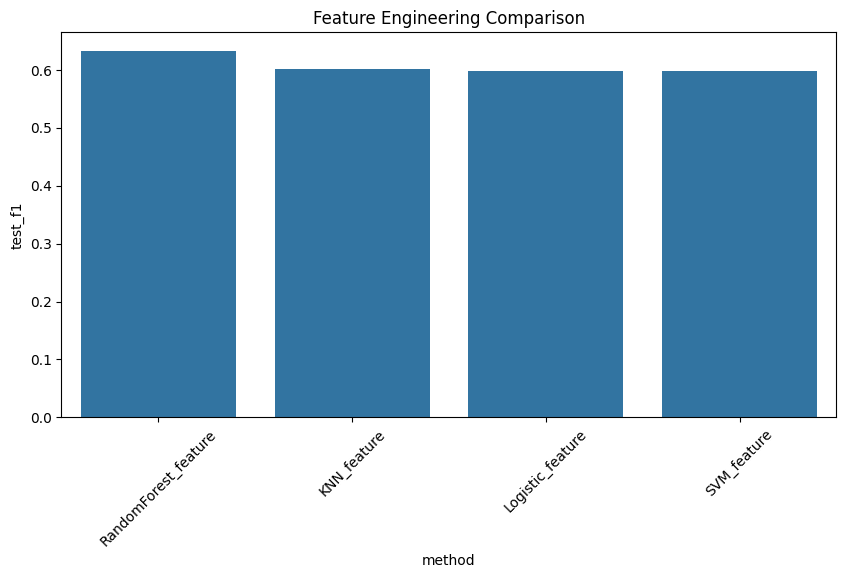

In [ ]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="test_f1", ascending=False)
display(df_results)

plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="method", y="test_f1")
plt.xticks(rotation=45)
plt.title("Feature Engineering Comparison")
plt.show()

### Tổng kết Version 4:
- Mô hình: Tiếp tục thử nghiệm và so sánh bộ 4 thuật toán (Logistic, RandomForest, SVM, KNN).

- Tiền xử lý: * Kế thừa bộ tiền xử lý từ các phiên bản trước (xử lý giá trị 0, chuẩn hóa dữ liệu).

  - Tập trung vào việc tạo ra các biến số mới có tính kết hợp cao như BMI_Age (tích giữa chỉ số BMI và Tuổi) và Glucose_BMI (tích giữa lượng Đường và chỉ số BMI).

  - Sử dụng StandardScaler để đảm bảo các đặc trưng mới và cũ đều nằm trên cùng một thang đo, tối ưu cho các thuật toán dựa trên khoảng cách.

- Kết quả: Việc tạo đặc trưng mới giúp mô hình khai thác được các mối quan hệ tương tác phi tuyến tính giữa các biến số sức khỏe.

  - Mô hình RandomForest thường cho kết quả ổn định và tốt nhất trên tập dữ liệu đã được làm giàu đặc trưng với chỉ số test_f1 đạt khoảng 0.6335.

  - Tạo tiền đề vững chắc cho bước tối ưu hóa siêu tham số (Hyperparameter Tuning) để đạt được hiệu suất tối đa.